In [23]:
import json
import numpy as np
import os
import eval_utils as evaluation
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Change accordingly
OUTPUT_DIR =f'/Users/administrador/Desktop/amsterdam/1.1/FACT/FACT29/our_games_descriptions/base/output/our_outputs/base_Qwen2.5-72B-Instruct-GPTQ-Int4'
AGENTS_NUM = 6
ISSUES_NUM = 5

In [25]:
# EXTRACT INFORMATION FROM GAME
agents, role_to_agents, incentive_to_agents = evaluation.load_setup(OUTPUT_DIR,AGENTS_NUM,ISSUES_NUM)
answers_files = [ os.path.join(OUTPUT_DIR,filename) for filename in os.listdir(OUTPUT_DIR) if filename.startswith("history")]

Size of the deal space: 720
Size of the feasibility set: 37
Ratio of feasible deals: 0.05138888888888889


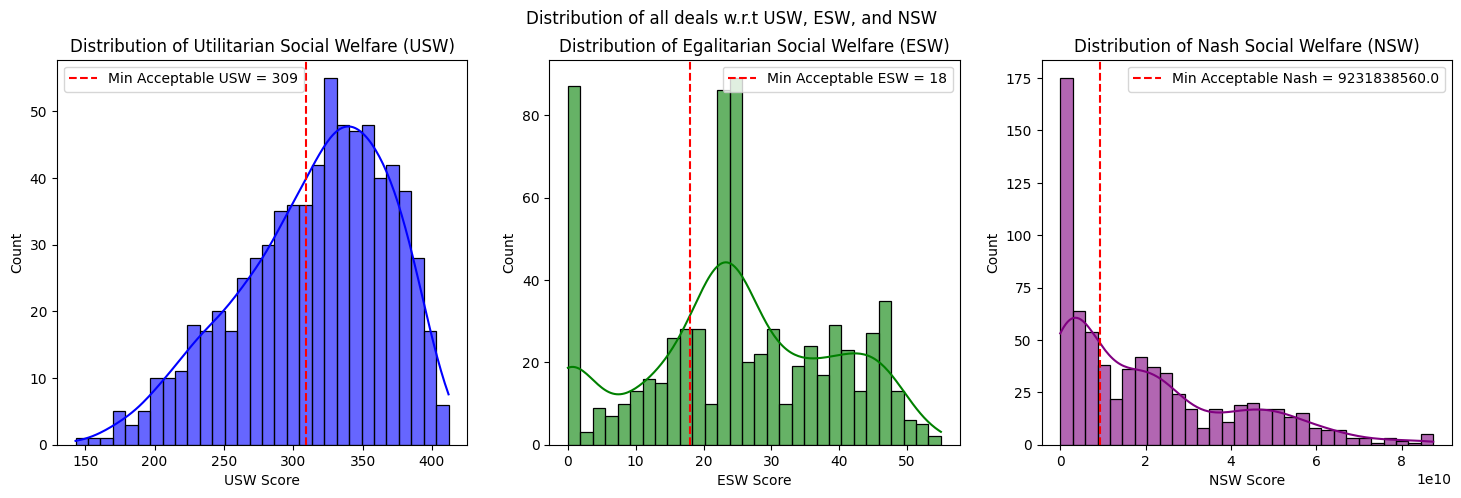

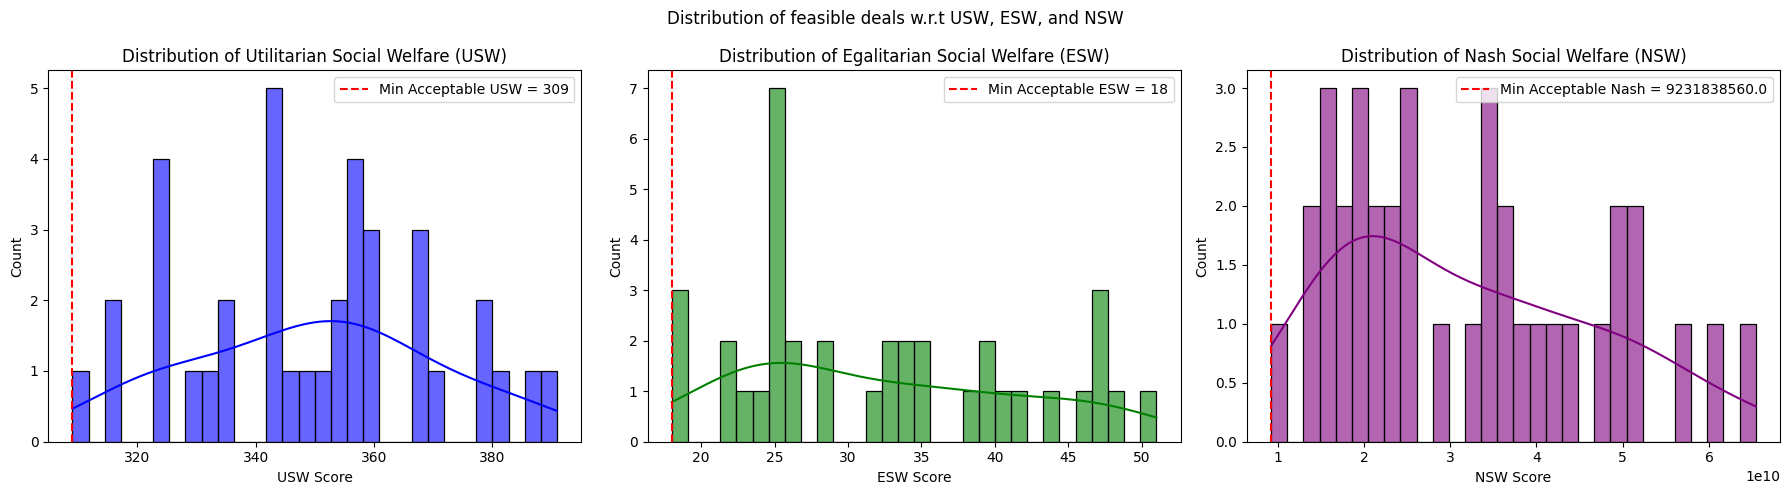

In [26]:
# GAME INFORMATION - Pre Hoc
# The informations shown here is independent of the agent's performance and it only reflects inherent game statistics

all_deals = evaluation.get_all_deals(agents)
feasibility_set = evaluation.compute_feasibility_set(agents, all_deals)
R = len(feasibility_set) / len(all_deals)

print(f"Size of the deal space: {len(all_deals)}")
print(f"Size of the feasibility set: {len(feasibility_set)}")
print(f"Ratio of feasible deals: {R}")

# TODO: Implement Sparsity and IoU

# Compute **social welfare metrics** for each deal
usw_scores = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in all_deals]
esw_scores = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in all_deals]
nash_scores = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in all_deals]

# Compute **minimal acceptable score** for each metric (minimum value of an accepted deal)
feasible_usw = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
feasible_esw = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
feasible_nash = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in feasibility_set]

min_usw = min(feasible_usw) if feasible_usw else 0
min_esw = min(feasible_esw) if feasible_esw else 0
min_nash = min(feasible_nash) if feasible_nash else 0

max_usw = max(feasible_usw) if feasible_usw else 0
max_esw = max(feasible_esw) if feasible_esw else 0
max_nash = max(feasible_nash) if feasible_nash else 0

# max_usw = max(usw_scores) if usw_scores else 0
# max_esw = max(esw_scores) if esw_scores else 0
# max_nash = max(nash_scores) if nash_scores else 0

# PLOT DISTRIBUTION OF DEALS FOR EACH METRIC (ALL DEALS)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Create 3 subplots
fig.suptitle("Distribution of all deals w.r.t USW, ESW, and NSW")

# Plot USW Distribution
sns.histplot(usw_scores, bins=30, kde=True, ax=axes[0], color="blue", alpha=0.6)
axes[0].axvline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].set_title("Distribution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("USW Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot ESW Distribution
sns.histplot(esw_scores, bins=30, kde=True, ax=axes[1], color="green", alpha=0.6)
axes[1].axvline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].set_title("Distribution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("ESW Score")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot Nash Social Welfare Distribution 
sns.histplot(nash_scores, bins=30, kde=True, ax=axes[2], color="purple", alpha=0.6)
axes[2].axvline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].set_title("Distribution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("NSW Score")
axes[2].set_ylabel("Count")
axes[2].legend()

# PLOT DISTRIBUTION OF DEALS FOR EACH METRIC (FEASIBLE DEALS)

# Compute **social welfare metrics** for each deal
usw_scores_feasible = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
esw_scores_feasible = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
nash_scores_feasible = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in feasibility_set]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Create 3 subplots
# Set the title of the plot
fig.suptitle("Distribution of feasible deals w.r.t USW, ESW, and NSW")

# Plot USW Distribution
sns.histplot(usw_scores_feasible, bins=30, kde=True, ax=axes[0], color="blue", alpha=0.6)
axes[0].axvline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].set_title("Distribution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("USW Score")
axes[0].set_ylabel("Count")
axes[0].legend()

# Plot ESW Distribution
sns.histplot(esw_scores_feasible, bins=30, kde=True, ax=axes[1], color="green", alpha=0.6)
axes[1].axvline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].set_title("Distribution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("ESW Score")
axes[1].set_ylabel("Count")
axes[1].legend()

# Plot Nash Social Welfare Distribution 
sns.histplot(nash_scores_feasible, bins=30, kde=True, ax=axes[2], color="purple", alpha=0.6)
axes[2].axvline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].set_title("Distribution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("NSW Score")
axes[2].set_ylabel("Count")
axes[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()

In [28]:
# Compute optimal sets (Sets of deals that maximize each metric)

optimal_usw_set, optimal_usw_value = evaluation.compute_optimal_usw(agents, feasibility_set, ISSUES_NUM)
optimal_esw_set, optimal_esw_value = evaluation.compute_optimal_esw(agents, feasibility_set, ISSUES_NUM)
optimal_nash_set, optimal_nash_value = evaluation.compute_optimal_nash(agents, feasibility_set, ISSUES_NUM)

print(f"Optimal USW set size: {len(optimal_usw_set)}")
print(f"Optimal USW set: {optimal_esw_set}")
print(f"Optimal ESW value: {optimal_esw_value}")
print("===========================================================")
print(f"Optimal ESW set size: {len(optimal_esw_set)}")
print(f"Optimal ESW set: {optimal_esw_set}")
print(f"Optimal ESW value: {optimal_esw_value}")
print("===========================================================")
print(f"Optimal Nash set size: {len(optimal_nash_set)}")
print(f"Optimal Nash set: {optimal_nash_set}")
print(f"Optimal Nash value: {optimal_nash_value}")

Optimal USW set size: 1
Optimal USW set: [(('A', 3), ('B', 2), ('C', 3), ('D', 2), ('E', 3))]
Optimal ESW value: 51
Optimal ESW set size: 1
Optimal ESW set: [(('A', 3), ('B', 2), ('C', 3), ('D', 2), ('E', 3))]
Optimal ESW value: 51
Optimal Nash set size: 1
Optimal Nash set: [(('A', 2), ('B', 3), ('C', 3), ('D', 2), ('E', 3))]
Optimal Nash value: 65425032288.0


1. Percentage of games achieving a feasible deal in the last step (5/6-way %): 80.00%
2. Percentage of games achieving a fully accepted deal in the last step (6-way %): 0.00%
3. Percentage of games achieving a feasible deal at any point (Any %): 95.00%


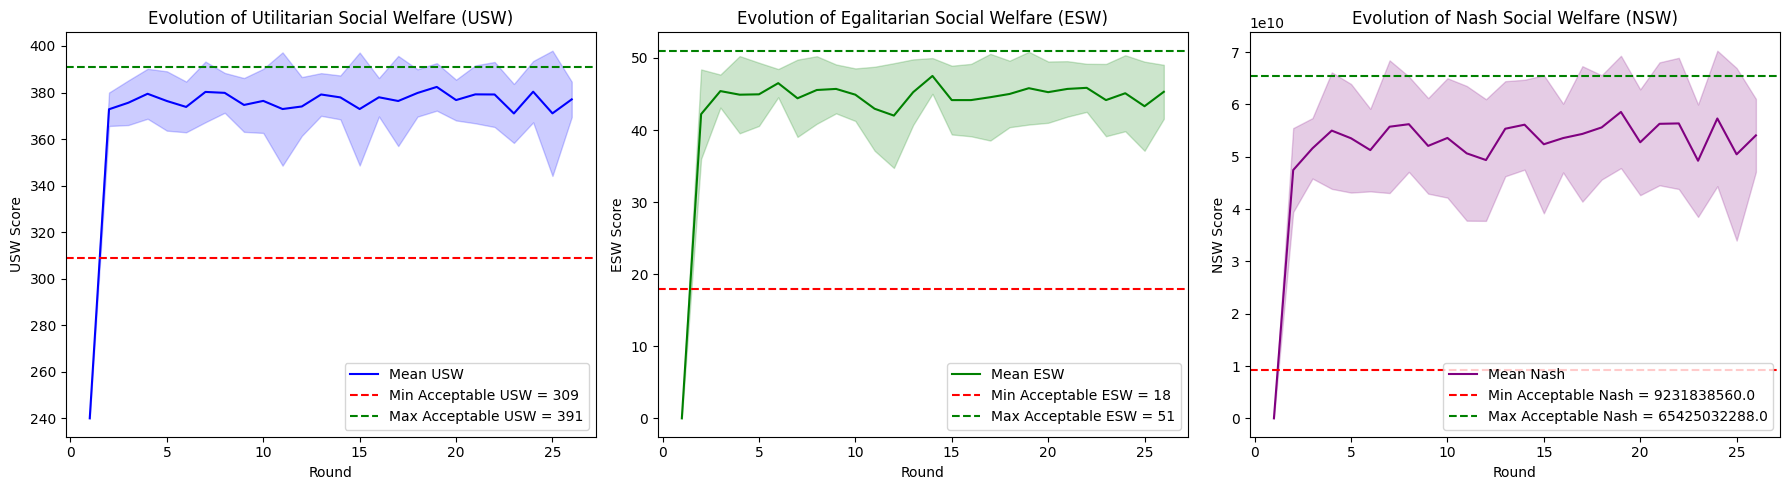

In [29]:
# GAME INFORMATION - Post Hoc

# Initialize lists to store scores per round across all games
num_rounds = None  # This will be determined dynamically
usw_scores, esw_scores, nash_scores = [], [], []

# Track statistics
feasible_in_last_step = 0
accepted_by_all_in_last_step = 0
contained_feasible_deal = 0

# Loop through all answer files (each represents a game)
for file_ in answers_files:
    answers = json.load(open(file_))

    # Extract deals for this game
    game_usw, game_esw, game_nash = [], [], []
    feasible_found = False

    # Extract the name of the first player to validate feasibility throughout the game
    p1_name = answers['rounds'][0]['agent']

    for i, round_ in enumerate(answers['rounds']):
        name, answer = round_['agent'], round_['public_answer']
        deal_unformatted, threshold = evaluation.extract_deal(answer, ISSUES_NUM)
        deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)

        # Compute scores for this round
        usw = evaluation.compute_usw(deal, agents, ISSUES_NUM)
        esw = evaluation.compute_esw(deal, agents, ISSUES_NUM)
        nash = evaluation.compute_nash(deal, agents, ISSUES_NUM)

        game_usw.append(usw)
        game_esw.append(esw)
        game_nash.append(nash)

        # Check if the deal was feasible at any point (Deal must have been proposed by p1)
        
        if evaluation.is_feasible(agents, deal) and name == p1_name:
            feasible_found = True

    # Store the game data
    usw_scores.append(game_usw)
    esw_scores.append(game_esw)
    nash_scores.append(game_nash)

    # Track the number of rounds
    if num_rounds is None:
        num_rounds = len(game_usw)
    else:
        assert len(game_usw) == num_rounds, "Mismatch in number of rounds between games"

    # CHECK GAME COMPLETION METRICS
    last_deal = evaluation.format_deal(evaluation.extract_deal(answers['rounds'][-1]['public_answer'], ISSUES_NUM)[0], ISSUES_NUM)
    

    # 1. Check if the last deal is feasible
    if evaluation.is_feasible(agents, last_deal):
        feasible_in_last_step += 1

    # 2. Check if the last deal is acceptable by all agents
    all_accept = all(evaluation.calculator(agents[agent]["scores"], last_deal, ISSUES_NUM) >= agents[agent]["scores"]["min"] for agent in agents)
    if all_accept:
        accepted_by_all_in_last_step += 1

    # 3. Check if any deal during the game was in the feasibility set
    if feasible_found:
        contained_feasible_deal += 1

# Convert lists to NumPy arrays for statistical calculations
usw_scores = np.array(usw_scores)  # Shape: (20, num_rounds)
esw_scores = np.array(esw_scores)
nash_scores = np.array(nash_scores)

# Compute mean and standard deviation
mean_usw, std_usw = np.mean(usw_scores, axis=0), np.std(usw_scores, axis=0)
mean_esw, std_esw = np.mean(esw_scores, axis=0), np.std(esw_scores, axis=0)
mean_nash, std_nash = np.mean(nash_scores, axis=0), np.std(nash_scores, axis=0)

# Compute percentages
num_games = len(answers_files)
perc_feasible_last = (feasible_in_last_step / num_games) * 100
perc_accepted_all_last = (accepted_by_all_in_last_step / num_games) * 100
perc_feasible_any = (contained_feasible_deal / num_games) * 100

# Print statistics
print(f"1. Percentage of games achieving a feasible deal in the last step (5/6-way %): {perc_feasible_last:.2f}%")
print(f"2. Percentage of games achieving a fully accepted deal in the last step (6-way %): {perc_accepted_all_last:.2f}%")
print(f"3. Percentage of games achieving a feasible deal at any point (Any %): {perc_feasible_any:.2f}%")

# Plot the evolution of scores over rounds
rounds = np.arange(1, num_rounds + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot USW Evolution
axes[0].plot(rounds, mean_usw, label="Mean USW", color="blue")
axes[0].axhline(min_usw, color="red", linestyle="--", label=f"Min Acceptable USW = {min_usw}")
axes[0].axhline(max_usw, color="green", linestyle="--", label=f"Max Acceptable USW = {max_usw}")
axes[0].fill_between(rounds, mean_usw - std_usw, mean_usw + std_usw, color="blue", alpha=0.2)
axes[0].set_title("Evolution of Utilitarian Social Welfare (USW)")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("USW Score")
axes[0].legend()

# Plot ESW Evolution
axes[1].plot(rounds, mean_esw, label="Mean ESW", color="green")
axes[1].axhline(min_esw, color="red", linestyle="--", label=f"Min Acceptable ESW = {min_esw}")
axes[1].axhline(max_esw, color="green", linestyle="--", label=f"Max Acceptable ESW = {max_esw}")
axes[1].fill_between(rounds, mean_esw - std_esw, mean_esw + std_esw, color="green", alpha=0.2)
axes[1].set_title("Evolution of Egalitarian Social Welfare (ESW)")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("ESW Score")
axes[1].legend()

# Plot Nash Evolution 
axes[2].plot(rounds, mean_nash, label="Mean Nash", color="purple")
axes[2].axhline(min_nash, color="red", linestyle="--", label=f"Min Acceptable Nash = {min_nash}")
axes[2].axhline(max_nash, color="green", linestyle="--", label=f"Max Acceptable Nash = {max_nash}")
axes[2].fill_between(rounds, mean_nash - std_nash, mean_nash + std_nash, color="purple", alpha=0.2)
axes[2].set_title("Evolution of Nash Social Welfare (NSW)")
axes[2].set_xlabel("Round")
axes[2].set_ylabel("NSW Score")
axes[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()